In [1]:
!pip install git+https://github.com/IBM/tsfm.git

  Cloning https://github.com/IBM/tsfm.git to /tmp/pip-req-build-ii5x9i15
  Running command git clone --filter=blob:none --quiet https://github.com/IBM/tsfm.git /tmp/pip-req-build-ii5x9i15
  Resolved https://github.com/IBM/tsfm.git to commit b2c51e7bbe632566239f735e9a2f622ce55dbfab
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [1]:
# Skip this cell after initial run
from google.colab import files
uploaded = files.upload() # load 2024

Saving Native_Load_2022.xlsx to Native_Load_2022.xlsx
Saving Native_Load_2023.xlsx to Native_Load_2023.xlsx
Saving Native_Load_2024.xlsx to Native_Load_2024.xlsx
Saving Native_Load_2025.xlsx to Native_Load_2025.xlsx
Saving 3957371.csv to 3957371.csv


In [2]:
import torch
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from transformers import PatchTSTConfig, PatchTSTForPrediction, Trainer, TrainingArguments
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from torch.utils.data import Dataset
from sklearn.model_selection import train_test_split

# Load and preprocess ERCOT data
def load_ercot_data(file_path):
    df = pd.read_excel(file_path, sheet_name='Sheet1')
    df['Hour Ending'] = df['Hour Ending'].str.replace(' 24:00', ' 00:00', regex=True)
    df['Hour Ending'] = pd.to_datetime(df['Hour Ending'], format='%m/%d/%Y %H:%M', errors='coerce') + pd.Timedelta(days=1)
    df.dropna(subset=['Hour Ending'], inplace=True)
    df.set_index('Hour Ending', inplace=True)
    return df

# Aggregate hourly data to daily data
def aggregate_to_daily(data):
    area_sums = data[['COAST', 'EAST', 'FWEST', 'NORTH', 'NCENT', 'SOUTH', 'SCENT', 'WEST']].resample('D').sum()
    ercot_sum = data['ERCOT'].resample('D').sum()
    daily_data = pd.concat([area_sums, ercot_sum], axis=1)
    return daily_data

# Load temperature data
def load_temperature_data(file_path):
    temp_df = pd.read_csv(file_path)
    temp_df['DATE'] = pd.to_datetime(temp_df['DATE'])
    temp_df = temp_df[['DATE', 'TAVG']]
    temp_df.set_index('DATE', inplace=True)
    return temp_df

# Normalize the data
def normalize_data(data, scaler=None):
    if scaler is None:
        scaler = StandardScaler()
        scaled_data = scaler.fit_transform(data)
    else:
        scaled_data = scaler.transform(data)
    return pd.DataFrame(scaled_data, index=data.index, columns=data.columns), scaler

# Load datasets
file_paths = ["Native_Load_2022.xlsx", "Native_Load_2023.xlsx", "Native_Load_2024.xlsx"]
temp_file_path = "3957371.csv"

daily_ercot_data = []
for file_path in file_paths:
    ercot_data = load_ercot_data(file_path)
    daily_ercot = aggregate_to_daily(ercot_data)
    daily_ercot_data.append(daily_ercot)

daily_ercot_all = pd.concat(daily_ercot_data)

# Load and merge temperature data
temp_data = load_temperature_data(temp_file_path)
daily_ercot_all = daily_ercot_all.merge(temp_data, left_index=True, right_index=True, how='left')

daily_ercot_all.fillna(method='ffill', inplace=True)
daily_ercot_all.fillna(method='bfill', inplace=True)

# Ensure no NaNs exist
if daily_ercot_all.isna().sum().sum() > 0:
    raise ValueError("Error: NaN values remain in the dataset after filling.")

# Normalize the data
normalized_data, scaler = normalize_data(daily_ercot_all)

# Prepare input and target data
context_length = 276
prediction_length = 30

def create_sequences(df):
    X, y = [], []
    for i in range(len(df) - context_length - prediction_length + 1):
        X.append(df[["ERCOT", "TAVG"]].iloc[i:i+context_length].values)
        y.append(df["ERCOT"].iloc[i+context_length:i+context_length+prediction_length].values)
    return torch.tensor(X, dtype=torch.float32), torch.tensor(y, dtype=torch.float32)

X_full, y_full = create_sequences(normalized_data)

# Split train and validation sets
train_size = int(0.8 * len(X_full))
X_train, X_val = X_full[:train_size], X_full[train_size:]
y_train, y_val = y_full[:train_size], y_full[train_size:]

if len(X_val) == 0:
    raise ValueError("Validation dataset is empty after splitting. Reduce train_size.")

if torch.isnan(X_val).any() or torch.isnan(y_val).any():
    raise ValueError("Error: NaN values detected in validation dataset.")

# Custom Dataset class
class TimeSeriesDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y.unsqueeze(-1) if y.dim() == 2 else y

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return {
            "past_values": self.X[idx],
            "future_values": self.y[idx],
            "labels": self.y[idx]
        }

# Create datasets
train_dataset = TimeSeriesDataset(X_train, y_train)
eval_dataset = TimeSeriesDataset(X_val, y_val)

# Define model configuration
config = PatchTSTConfig(
    num_input_channels=2,
    prediction_length=prediction_length,
    context_length=context_length,
    patch_length=16,
    patch_stride=8,
    num_hidden_layers=4,
    d_model=128,
    num_attention_heads=4,
    ffn_dim=256,
    norm_type='layernorm',
    positional_encoding_type='sincos'
)

model = PatchTSTForPrediction(config)

# Define training arguments
training_args = TrainingArguments(
    output_dir="./results",
    logging_dir="./logs",
    logging_steps=10,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=25,
    save_strategy="epoch",
    evaluation_strategy="epoch",
    learning_rate=1e-4,
    weight_decay=0.01,
    disable_tqdm=False,
    report_to="none"
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset
)

# Train the model
trainer.train()

<ipython-input-2-098a92332fca>:59: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  daily_ercot_all.fillna(method='ffill', inplace=True)
<ipython-input-2-098a92332fca>:60: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  daily_ercot_all.fillna(method='bfill', inplace=True)
<ipython-input-2-098a92332fca>:78: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:254.)
  return torch.tensor(X, dtype=torch.float32), torch.tensor(y, dtype=torch.float32)
/usr/local/lib/python3.11/dist-packages/transformers/training_args.py:1575: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of

Epoch,Training Loss,Validation Loss
1,1.094800,No log
2,0.482800,No log
3,0.360500,No log
4,0.313400,No log
5,0.275000,No log
6,0.276000,No log
7,0.300100,No log
8,0.314100,No log
9,0.278200,No log
10,0.251800,No log


/usr/local/lib/python3.11/dist-packages/torch/nn/modules/loss.py:610: UserWarning: Using a target size (torch.Size([8, 30, 1])) that is different to the input size (torch.Size([8, 30, 2])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)
/usr/local/lib/python3.11/dist-packages/torch/nn/modules/loss.py:610: UserWarning: Using a target size (torch.Size([15, 30, 1])) that is different to the input size (torch.Size([15, 30, 2])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)
/usr/local/lib/python3.11/dist-packages/torch/nn/modules/loss.py:610: UserWarning: Using a target size (torch.Size([16, 30, 1])) that is different to the input size (torch.Size([16, 30, 2])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same s

TrainOutput(global_step=1000, training_loss=0.33936301493644716, metrics={'train_runtime': 129.8523, 'train_samples_per_second': 121.677, 'train_steps_per_second': 7.701, 'total_flos': 28267926624000.0, 'train_loss': 0.33936301493644716, 'epoch': 25.0})

In [3]:
# Define evaluation function
def evaluate_model(model, dataset, scaler):
    model.eval()
    all_predictions = []
    all_targets = []
    X_data, y_data = dataset

    if len(X_data) == 0:
        print("Error: Evaluation dataset is empty!")
        return np.array([]), None, None

    for i in range(len(X_data)):
        input_data = X_data[i].clone().detach().unsqueeze(0)
        target_data = y_data[i].clone().detach().unsqueeze(0)

        with torch.no_grad():
            output = model(past_values=input_data)
            if output.prediction_outputs is None:
                print(f"Warning: No prediction generated for sample {i}")
                continue

            predictions = output.prediction_outputs[..., 0].unsqueeze(-1).numpy()
            all_predictions.append(predictions)
            all_targets.append(target_data.numpy().squeeze())

    if len(all_predictions) != len(all_targets):
        print(f"Error: Mismatch in dataset sizes. Predictions: {len(all_predictions)}, Targets: {len(all_targets)}")
        return np.array([]), None, None

    all_predictions = np.nan_to_num(np.array(all_predictions).reshape(len(all_predictions), -1))
    all_targets = np.nan_to_num(np.array(all_targets).reshape(len(all_targets), -1))

    mse = mean_squared_error(all_targets, all_predictions)
    mae = mean_absolute_error(all_targets, all_predictions)
    rmse = np.sqrt(mse)
    r2 = r2_score(all_targets, all_predictions)

    print(f"MSE: {mse:.4f}, MAE: {mae:.4f}, R^2: {r2:.4f}")

    return all_predictions, mse, mae  # Return errors for unnormalization

# Unnormalize the errors
def unnormalize_error(mse, mae, scaler, target_column="ERCOT"):
    std_y = scaler.scale_[daily_ercot_all.columns.get_loc(target_column)]  # Get std from scaler
    unnormalized_mse = mse * (std_y ** 2)  # Reverse variance scaling
    unnormalized_mae = mae * std_y  # Reverse standard deviation scaling
    return unnormalized_mse, unnormalized_mae

# Run evaluation
predictions, mse, mae = evaluate_model(model, (X_val, y_val), scaler)

if mse is not None and mae is not None:
    unnormalized_mse, unnormalized_mae = unnormalize_error(mse, mae, scaler)
    print(f"Unnormalized MSE: {unnormalized_mse:.4f}")
    print(f"Unnormalized MAE: {unnormalized_mae:.4f}")

MSE: 0.3845, MAE: 0.4876, R^2: 0.4973
Unnormalized MSE: 16597342556.2089
Unnormalized MAE: 101291.6168


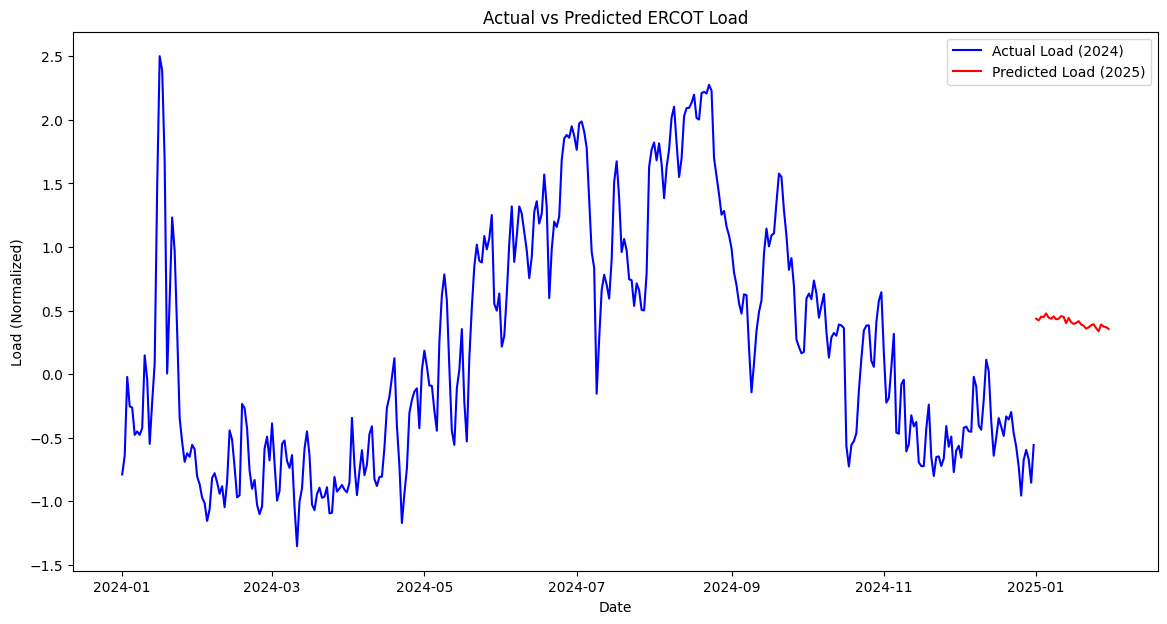

In [5]:
import matplotlib.pyplot as plt

# Extract last 30 days of ERCOT predictions
ercot_predictions = predictions[:, -30:] if predictions.ndim == 2 else predictions[:, -30:, 0]  # Get the last 30 days for ERCOT

# Calculate the mean of the predictions across the samples
ercot_predictions_mean = ercot_predictions.mean(axis=0)

# Generate forecast dates (30 days after the last date in the original dataset)
normalized_2024 = normalized_data.loc["2024"]  # Extract 2024 data

forecast_dates = pd.date_range(start=normalized_2024.index[-1] + pd.Timedelta(days=1), periods=30)

# Create a DataFrame with the forecast dates and predicted ERCOT load
forecast_df = pd.DataFrame(ercot_predictions_mean, index=forecast_dates, columns=['ERCOT'])

# Plot the actual and predicted loads
plt.figure(figsize=(14, 7))
plt.plot(normalized_2024.index, normalized_2024['ERCOT'], label='Actual Load (2024)', color='blue')
plt.plot(forecast_dates, forecast_df['ERCOT'], label='Predicted Load (2025)', color='red')
plt.xlabel('Date')
plt.ylabel('Load (Normalized)')
plt.title('Actual vs Predicted ERCOT Load')
plt.legend()
plt.show()

<ipython-input-6-f98867e77aa9>:10: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  daily_ercot_2025.fillna(method='ffill', inplace=True)
<ipython-input-6-f98867e77aa9>:11: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  daily_ercot_2025.fillna(method='bfill', inplace=True)


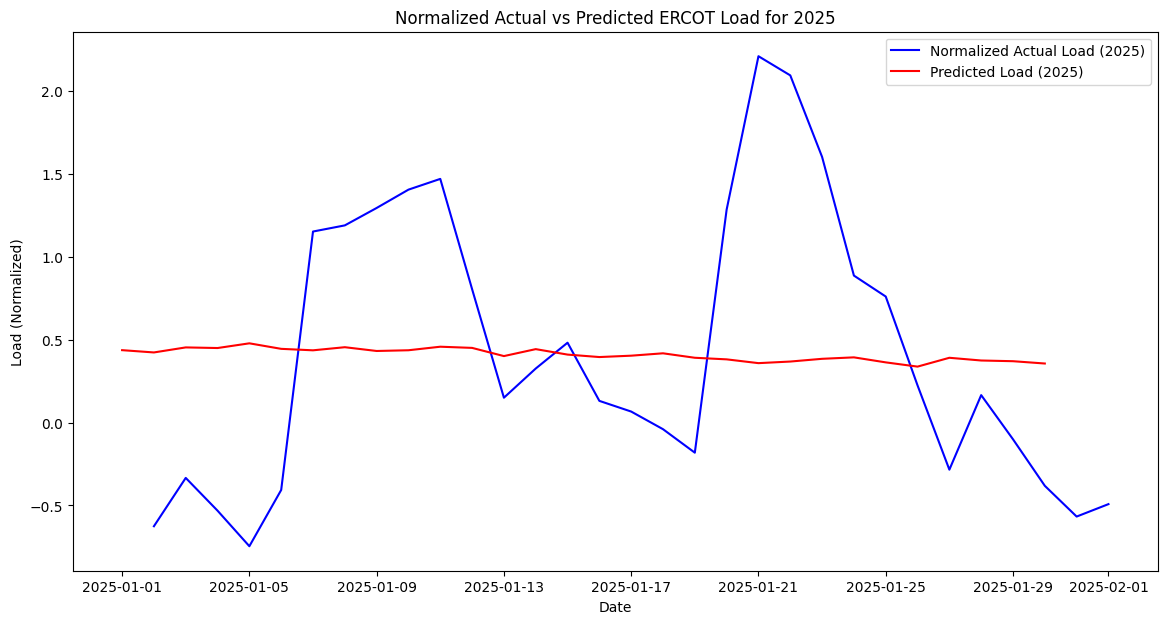

In [6]:
# Load and preprocess 2025 data
file_path_2025 = "Native_Load_2025.xlsx"
df2 = load_ercot_data(file_path_2025)
daily_ercot_2025 = aggregate_to_daily(df2)

temp_file_path = "3957371.csv"
temp_data = load_temperature_data(temp_file_path)

daily_ercot_2025 = daily_ercot_2025.merge(temp_data, left_index=True, right_index=True, how='left')
daily_ercot_2025.fillna(method='ffill', inplace=True)
daily_ercot_2025.fillna(method='bfill', inplace=True)

# Ensure no NaNs exist
if daily_ercot_2025.isna().sum().sum() > 0:
    raise ValueError("Error: NaN values remain in the 2025 dataset after filling.")

# Normalize actual load (2025)
normalized_actual_load_2025, _ = normalize_data(daily_ercot_2025, scaler)

# Plot normalized actual vs predicted loads
plt.figure(figsize=(14, 7))
plt.plot(normalized_actual_load_2025.index, normalized_actual_load_2025['ERCOT'], label='Normalized Actual Load (2025)', color='blue')
plt.plot(forecast_dates, forecast_df['ERCOT'], label='Predicted Load (2025)', color='red')
plt.xlabel('Date')
plt.ylabel('Load (Normalized)')
plt.title('Normalized Actual vs Predicted ERCOT Load for 2025')
plt.legend()
plt.show()
